# Phase 3: Predictive Modeling


## Data Validation and Preparation

In [490]:
import pandas as pd
from pathlib import Path
import numpy as np

In [491]:
DATA_PATH = Path("../data/processed/team_game_logs_clean.csv")

df = pd.read_csv(
    DATA_PATH,
    dtype={
        "GAME_ID": "string",
        "SEASON": "string",
        "TEAM_ID": "Int64",
    },
    parse_dates=["GAME_DATE"],
)

print(df.shape)
df.head()

(12300, 36)


,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,PTS,PLUS_MINUS,VIDEO_AVAILABLE,SEASON,SEASON_TYPE,WIN,HOME_GAME,AWAY_GAME,OPPONENT_ABBREVIATION,TEAM_GAME_NUMBER
0,22021,1610612749,MIL,Milwaukee Bucks,0022100001,2021-10-19,MIL vs. BKN,W,240,48,...,127,23,1,2021-22,Regular Season,1,1,0,BKN,1
1,22021,1610612751,BKN,Brooklyn Nets,0022100001,2021-10-19,BKN @ MIL,L,240,37,...,104,-23,1,2021-22,Regular Season,0,0,1,MIL,1
2,22021,1610612744,GSW,Golden State Warriors,0022100002,2021-10-19,GSW @ LAL,W,240,41,...,121,7,1,2021-22,Regular Season,1,0,1,LAL,1
3,22021,1610612747,LAL,Los Angeles Lakers,0022100002,2021-10-19,LAL vs. GSW,L,240,45,...,114,-7,1,2021-22,Regular Season,0,1,0,GSW,1
4,22021,1610612754,IND,Indiana Pacers,0022100003,2021-10-20,IND @ CHA,L,240,42,...,122,-1,1,2021-22,Regular Season,0,0,1,CHA,1


In [492]:
'''Check columns'''
df.columns.tolist()

['SEASON_ID',
 'TEAM_ID',
 'TEAM_ABBREVIATION',
 'TEAM_NAME',
 'GAME_ID',
 'GAME_DATE',
 'MATCHUP',
 'WL',
 'MIN',
 'FGM',
 'FGA',
 'FG_PCT',
 'FG3M',
 'FG3A',
 'FG3_PCT',
 'FTM',
 'FTA',
 'FT_PCT',
 'OREB',
 'DREB',
 'REB',
 'AST',
 'STL',
 'BLK',
 'TOV',
 'PF',
 'PTS',
 'PLUS_MINUS',
 'VIDEO_AVAILABLE',
 'SEASON',
 'SEASON_TYPE',
 'WIN',
 'HOME_GAME',
 'AWAY_GAME',
 'OPPONENT_ABBREVIATION',
 'TEAM_GAME_NUMBER']

In [493]:
'''Check required columns'''
required_columns = [
    "SEASON",
    "GAME_ID",
    "GAME_DATE",
    "TEAM_ID",
    "TEAM_NAME",
    "MATCHUP",
    "WL",
    "WIN",
    "HOME_GAME",
    "AWAY_GAME",
    "OPPONENT_ABBREVIATION",
    "TEAM_GAME_NUMBER",
    "PTS",
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

print("Missing columns:", missing_columns)

Missing columns: []


In [494]:
'''Check data range'''
print("First game:", df["GAME_DATE"].min())
print("Last game:", df["GAME_DATE"].max())

First game: 2021-10-19 00:00:00
Last game: 2026-04-12 00:00:00


In [495]:
'''Check duplicate team rows'''
print("Duplicate team-game rows:")
print(df.duplicated(["GAME_ID", "TEAM_ID"]).sum())
'''Check missing target values'''
print("\nMissing target values:")
print(df["WIN"].isna().sum())


Duplicate team-game rows:
0

Missing target values:
0


In [496]:
'''Check missing values and number of teams'''
print("\nMissing values:")
print(df.isna().sum())

'''Check number of teams'''
df.groupby("SEASON")["TEAM_ID"].nunique()


Missing values:
SEASON_ID                0
TEAM_ID                  0
TEAM_ABBREVIATION        0
TEAM_NAME                0
GAME_ID                  0
GAME_DATE                0
MATCHUP                  0
WL                       0
MIN                      0
FGM                      0
FGA                      0
FG_PCT                   0
FG3M                     0
FG3A                     0
FG3_PCT                  0
FTM                      0
FTA                      0
FT_PCT                   1
OREB                     0
DREB                     0
REB                      0
AST                      0
STL                      0
BLK                      0
TOV                      0
PF                       0
PTS                      0
PLUS_MINUS               0
VIDEO_AVAILABLE          0
SEASON                   0
SEASON_TYPE              0
WIN                      0
HOME_GAME                0
AWAY_GAME                0
OPPONENT_ABBREVIATION    0
TEAM_GAME_NUMBER         0
dtype: int6

SEASON
2021-22    30
2022-23    30
2023-24    30
2024-25    30
2025-26    30
Name: TEAM_ID, dtype: int64

In [497]:
'''Check summary statistics'''
season_summary = (
    df.groupby("SEASON")
    .agg(
        TEAM_GAME_ROWS=("GAME_ID", "size"),
        UNIQUE_GAMES=("GAME_ID", "nunique"),
        TEAMS=("TEAM_ID", "nunique"),
        FIRST_GAME=("GAME_DATE", "min"),
        LAST_GAME=("GAME_DATE", "max"),
    )
    .reset_index()
)

season_summary

,SEASON,TEAM_GAME_ROWS,UNIQUE_GAMES,TEAMS,FIRST_GAME,LAST_GAME
0,2021-22,2460,1230,30,2021-10-19,2022-04-10
1,2022-23,2460,1230,30,2022-10-18,2023-04-09
2,2023-24,2460,1230,30,2023-10-24,2024-04-14
3,2024-25,2460,1230,30,2024-10-22,2025-04-13
4,2025-26,2460,1230,30,2025-10-21,2026-04-12


### Set Up Rolling Features

In [498]:
df = (
    df.sort_values(
        [
            "TEAM_ID",
            "SEASON",
            "GAME_DATE",
            "GAME_ID",
        ]
    )
    .reset_index(drop=True)
)

df.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,PTS,PLUS_MINUS,VIDEO_AVAILABLE,SEASON,SEASON_TYPE,WIN,HOME_GAME,AWAY_GAME,OPPONENT_ABBREVIATION,TEAM_GAME_NUMBER
0,22021,1610612737,ATL,Atlanta Hawks,0022100014,2021-10-21,ATL vs. DAL,W,240,45,...,113,26,1,2021-22,Regular Season,1,1,0,DAL,1
1,22021,1610612737,ATL,Atlanta Hawks,0022100027,2021-10-23,ATL @ CLE,L,240,38,...,95,-6,1,2021-22,Regular Season,0,0,1,CLE,2
2,22021,1610612737,ATL,Atlanta Hawks,0022100043,2021-10-25,ATL vs. DET,W,240,46,...,122,18,1,2021-22,Regular Season,1,1,0,DET,3
3,22021,1610612737,ATL,Atlanta Hawks,0022100059,2021-10-27,ATL @ NOP,W,240,40,...,102,3,1,2021-22,Regular Season,1,0,1,NOP,4
4,22021,1610612737,ATL,Atlanta Hawks,0022100066,2021-10-28,ATL @ WAS,L,240,48,...,111,-11,1,2021-22,Regular Season,0,0,1,WAS,5


In [499]:
df["PREV_WIN"] = (
    df.groupby(["SEASON", "TEAM_ID"])["WIN"]
      .shift(1)
)

df["PREV_PTS"] = (
    df.groupby(["SEASON", "TEAM_ID"])["PTS"]
      .shift(1)
)

df["PREV_WINS"] = (
    df.groupby(["SEASON", "TEAM_ID"])["WIN"]
      .cumsum()
      - df["WIN"]
)

df["PREV_GAMES"] = (
    df.groupby(["SEASON", "TEAM_ID"])
      .cumcount()
)

df["SEASON_WIN_PCT"] = (
    df["PREV_WINS"] / df["PREV_GAMES"]
)
df.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,WIN,HOME_GAME,AWAY_GAME,OPPONENT_ABBREVIATION,TEAM_GAME_NUMBER,PREV_WIN,PREV_PTS,PREV_WINS,PREV_GAMES,SEASON_WIN_PCT
0,22021,1610612737,ATL,Atlanta Hawks,0022100014,2021-10-21,ATL vs. DAL,W,240,45,...,1,1,0,DAL,1,NaN,NaN,0,0,NaN
1,22021,1610612737,ATL,Atlanta Hawks,0022100027,2021-10-23,ATL @ CLE,L,240,38,...,0,0,1,CLE,2,1.0,113.0,1,1,1.000000
2,22021,1610612737,ATL,Atlanta Hawks,0022100043,2021-10-25,ATL vs. DET,W,240,46,...,1,1,0,DET,3,0.0,95.0,1,2,0.500000
3,22021,1610612737,ATL,Atlanta Hawks,0022100059,2021-10-27,ATL @ NOP,W,240,40,...,1,0,1,NOP,4,1.0,122.0,2,3,0.666667
4,22021,1610612737,ATL,Atlanta Hawks,0022100066,2021-10-28,ATL @ WAS,L,240,48,...,0,0,1,WAS,5,1.0,102.0,3,4,0.750000


In [500]:
rolling_columns = [
    "PTS",
    "FG_PCT",
    "FG3_PCT",
    "FT_PCT",
    "REB",
    "AST",
    "STL",
    "BLK",
    "TOV",
    "PLUS_MINUS",
]

for column in rolling_columns:

    df[f"{column}_ROLL5"] = (
        df.groupby(["SEASON", "TEAM_ID"])[column]
          .transform(
              lambda x:
              x.shift(1)
               .rolling(
                   window=5,
                   min_periods=1,
               )
               .mean()
          )
    )

df["WIN_PCT_ROLL5"] = (
    df.groupby(["SEASON", "TEAM_ID"])["WIN"]
      .transform(
          lambda x:
          x.shift(1)
           .rolling(
               window=5,
               min_periods=1,
           )
           .mean()
      )
)
df.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,FG_PCT_ROLL5,FG3_PCT_ROLL5,FT_PCT_ROLL5,REB_ROLL5,AST_ROLL5,STL_ROLL5,BLK_ROLL5,TOV_ROLL5,PLUS_MINUS_ROLL5,WIN_PCT_ROLL5
0,22021,1610612737,ATL,Atlanta Hawks,0022100014,2021-10-21,ATL vs. DAL,W,240,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,22021,1610612737,ATL,Atlanta Hawks,0022100027,2021-10-23,ATL @ CLE,L,240,38,...,0.47900,0.42900,0.8890,55.000000,31.0,8.0,9.00,13.000000,26.000000,1.000000
2,22021,1610612737,ATL,Atlanta Hawks,0022100043,2021-10-25,ATL vs. DET,W,240,46,...,0.43150,0.36150,0.7445,54.500000,25.5,6.5,6.00,11.000000,10.000000,0.500000
3,22021,1610612737,ATL,Atlanta Hawks,0022100059,2021-10-27,ATL @ NOP,W,240,40,...,0.45800,0.36600,0.7820,52.666667,25.0,8.0,5.00,12.666667,12.666667,0.666667
4,22021,1610612737,ATL,Atlanta Hawks,0022100066,2021-10-28,ATL @ WAS,L,240,48,...,0.44775,0.34125,0.7925,53.250000,24.0,7.0,4.75,12.250000,10.250000,0.750000


In [501]:
df["WIN_PCT_ROLL5"] = (
    df.groupby(["SEASON", "TEAM_ID"])["WIN"]
      .transform(
          lambda x:
          x.shift(1)
           .rolling(
               window=5,
               min_periods=1,
           )
           .mean()
      )
)

df["REST_DAYS"] = (
    df.groupby(["SEASON", "TEAM_ID"])["GAME_DATE"]
      .diff()
      .dt.days
)

df["WIN_STREAK"] = (
    df.groupby(["SEASON", "TEAM_ID"])["WIN"]
      .transform(
          lambda x: (
              x.shift(1)
               .fillna(0)
               .groupby(
                   (
                       x.shift(1)
                       != x.shift(1).shift()
                   ).cumsum()
               )
               .cumsum()
          )
      )
)

df.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,FT_PCT_ROLL5,REB_ROLL5,AST_ROLL5,STL_ROLL5,BLK_ROLL5,TOV_ROLL5,PLUS_MINUS_ROLL5,WIN_PCT_ROLL5,REST_DAYS,WIN_STREAK
0,22021,1610612737,ATL,Atlanta Hawks,0022100014,2021-10-21,ATL vs. DAL,W,240,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,22021,1610612737,ATL,Atlanta Hawks,0022100027,2021-10-23,ATL @ CLE,L,240,38,...,0.8890,55.000000,31.0,8.0,9.00,13.000000,26.000000,1.000000,2.0,1.0
2,22021,1610612737,ATL,Atlanta Hawks,0022100043,2021-10-25,ATL vs. DET,W,240,46,...,0.7445,54.500000,25.5,6.5,6.00,11.000000,10.000000,0.500000,2.0,0.0
3,22021,1610612737,ATL,Atlanta Hawks,0022100059,2021-10-27,ATL @ NOP,W,240,40,...,0.7820,52.666667,25.0,8.0,5.00,12.666667,12.666667,0.666667,2.0,1.0
4,22021,1610612737,ATL,Atlanta Hawks,0022100066,2021-10-28,ATL @ WAS,L,240,48,...,0.7925,53.250000,24.0,7.0,4.75,12.250000,10.250000,0.750000,1.0,2.0


### Opponent Features

In [502]:
opponent_feature_columns = [
    "PTS_ROLL5",
    "FG_PCT_ROLL5",
    "FG3_PCT_ROLL5",
    "FT_PCT_ROLL5",
    "REB_ROLL5",
    "AST_ROLL5",
    "STL_ROLL5",
    "BLK_ROLL5",
    "TOV_ROLL5",
    "PLUS_MINUS_ROLL5",
    "WIN_PCT_ROLL5",
    "REST_DAYS",
]

opponent_df = df[
    [
        "SEASON",
        "GAME_ID",
        "TEAM_ID",
        "TEAM_NAME",
        *opponent_feature_columns,
    ]
].copy()

opponent_df = opponent_df.rename(
    columns={
        "TEAM_ID": "OPPONENT_TEAM_ID",
        "TEAM_NAME": "OPPONENT_TEAM_NAME",
        **{
            column: f"OPP_{column}"
            for column in opponent_feature_columns
        },
    }
)

df = df.merge(
    opponent_df,
    on=[
        "SEASON",
        "GAME_ID",
    ],
    how="left",
)

df = df[
    df["TEAM_ID"] != df["OPPONENT_TEAM_ID"]
].copy()

df = df.reset_index(drop=True)

In [503]:
print(df.shape)

df[
    [
        "GAME_ID",
        "TEAM_NAME",
        "OPPONENT_TEAM_NAME",
        "PTS_ROLL5",
        "OPP_PTS_ROLL5",
        "WIN_PCT_ROLL5",
        "OPP_WIN_PCT_ROLL5",
    ]
].head(10)

(12300, 68)


,GAME_ID,TEAM_NAME,OPPONENT_TEAM_NAME,PTS_ROLL5,OPP_PTS_ROLL5,WIN_PCT_ROLL5,OPP_WIN_PCT_ROLL5
0,0022100014,Atlanta Hawks,Dallas Mavericks,NaN,NaN,NaN,NaN
1,0022100027,Atlanta Hawks,Cleveland Cavaliers,113.0,116.50,1.000000,0.00
2,0022100043,Atlanta Hawks,Detroit Pistons,104.0,85.00,0.500000,0.00
3,0022100059,Atlanta Hawks,New Orleans Pelicans,110.0,101.25,0.666667,0.25
4,0022100066,Atlanta Hawks,Washington Wizards,108.0,109.75,0.750000,0.75
5,0022100082,Atlanta Hawks,Philadelphia 76ers,108.6,110.00,0.600000,0.60
6,0022100097,Atlanta Hawks,Washington Wizards,104.8,115.60,0.400000,0.80
7,0022100113,Atlanta Hawks,Brooklyn Nets,109.4,102.80,0.600000,0.60
8,0022100120,Atlanta Hawks,Utah Jazz,106.6,113.80,0.400000,0.80
9,0022100137,Atlanta Hawks,Phoenix Suns,105.8,109.60,0.200000,0.60


In [504]:
'''Check number of game_id per game to be 2'''
df.groupby(
    [
        "SEASON",
        "GAME_ID",
    ]
).size().value_counts()

2    6150
Name: count, dtype: int64

In [505]:
df["PTS_ROLL5_DIFF"] = (
    df["PTS_ROLL5"]
    - df["OPP_PTS_ROLL5"]
)

df["FG_PCT_ROLL5_DIFF"] = (
    df["FG_PCT_ROLL5"]
    - df["OPP_FG_PCT_ROLL5"]
)

df["FG3_PCT_ROLL5_DIFF"] = (
    df["FG3_PCT_ROLL5"]
    - df["OPP_FG3_PCT_ROLL5"]
)

df["REB_ROLL5_DIFF"] = (
    df["REB_ROLL5"]
    - df["OPP_REB_ROLL5"]
)

df["AST_ROLL5_DIFF"] = (
    df["AST_ROLL5"]
    - df["OPP_AST_ROLL5"]
)

df["TOV_ROLL5_DIFF"] = (
    df["TOV_ROLL5"]
    - df["OPP_TOV_ROLL5"]
)

df["PLUS_MINUS_ROLL5_DIFF"] = (
    df["PLUS_MINUS_ROLL5"]
    - df["OPP_PLUS_MINUS_ROLL5"]
)

df["WIN_PCT_ROLL5_DIFF"] = (
    df["WIN_PCT_ROLL5"]
    - df["OPP_WIN_PCT_ROLL5"]
)

df["REST_DAYS_DIFF"] = (
    df["REST_DAYS"]
    - df["OPP_REST_DAYS"]
)

### Save Modeling Dataset

In [506]:
output_path = Path(
    "../data/processed/team_game_modeling.csv"
)

df.to_csv(
    output_path,
    index=False,
)

print(f"Saved to: {output_path}")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")

Saved to: ../data/processed/team_game_modeling.csv
Rows: 12,300
Columns: 77


## Model Preparation

### Train/Test Split

In [507]:
train_df = df[df["SEASON"] != "2025-26"].copy()

test_df = df[df["SEASON"] == "2025-26"].copy()

### Choosing Features and Target

In [508]:
features = [
    # Location
    "HOME_GAME",
    "REST_DAYS",

    # Team season performance
    "SEASON_WIN_PCT",
    "TEAM_GAME_NUMBER",

    # Recent form
    "PTS_ROLL5",
    "FG_PCT_ROLL5",
    "FG3_PCT_ROLL5",
    "FT_PCT_ROLL5",
    "REB_ROLL5",
    "AST_ROLL5",
    "STL_ROLL5",
    "BLK_ROLL5",
    "TOV_ROLL5",
    "PLUS_MINUS_ROLL5",
    "WIN_PCT_ROLL5",

    # Opponent recent form
    "OPP_PTS_ROLL5",
    "OPP_FG_PCT_ROLL5",
    "OPP_FG3_PCT_ROLL5",
    "OPP_FT_PCT_ROLL5",
    "OPP_REB_ROLL5",
    "OPP_AST_ROLL5",
    "OPP_STL_ROLL5",
    "OPP_BLK_ROLL5",
    "OPP_TOV_ROLL5",
    "OPP_PLUS_MINUS_ROLL5",
    "OPP_WIN_PCT_ROLL5",
    "OPP_REST_DAYS",

    # Team vs opponent
    "PTS_ROLL5_DIFF",
    "FG_PCT_ROLL5_DIFF",
    "FG3_PCT_ROLL5_DIFF",
    "REB_ROLL5_DIFF",
    "AST_ROLL5_DIFF",
    "TOV_ROLL5_DIFF",
    "PLUS_MINUS_ROLL5_DIFF",
    "WIN_PCT_ROLL5_DIFF",
    "REST_DAYS_DIFF",
]

In [509]:
target = "WIN"

In [510]:
'''Drop rows with missing feature values'''
train_df = train_df.dropna(subset=features)

test_df = test_df.dropna(subset=features)

### Split X and Y

For this model, we will be using the 2021-2025 season to test 2025-2026 season predictions and results

In [511]:
train_df = df[df["SEASON"] != "2025-26"].copy()
test_df = df[df["SEASON"] == "2025-26"].copy()

print(train_df["SEASON"].value_counts().sort_index())
print()
print(test_df["SEASON"].value_counts().sort_index())

SEASON
2021-22    2460
2022-23    2460
2023-24    2460
2024-25    2460
Name: count, dtype: Int64

SEASON
2025-26    2460
Name: count, dtype: Int64


In [512]:
train_df = train_df.dropna(subset=features)
test_df = test_df.dropna(subset=features)

print(len(train_df))
print(len(test_df))

9714
2428


In [513]:
X_train = train_df[features]

y_train = train_df[target]

X_test = test_df[features]

y_test = test_df[target]

In [514]:
print("Training Features:", X_train.shape)
print("Training Labels:", y_train.shape)

print()

print("Testing Features:", X_test.shape)
print("Testing Labels:", y_test.shape)

Training Features: (9714, 36)
Training Labels: (9714,)

Testing Features: (2428, 36)
Testing Labels: (2428,)


## Logistic Regression

In [515]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

### Build Model

In [516]:
logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                random_state=42,
                max_iter=1000,
            ),
        ),
    ]
)


### Train

In [517]:
logistic_model.fit(
    X_train,
    y_train,
)

print("Training complete.")

Training complete.


### Coefficients

In [518]:
import pandas as pd

coefficients = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Coefficient": logistic_model.named_steps["classifier"].coef_[0],
    }
)

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
2,SEASON_WIN_PCT,0.373497
0,HOME_GAME,0.226107
33,PLUS_MINUS_ROLL5_DIFF,0.186642
35,REST_DAYS_DIFF,0.090764
13,PLUS_MINUS_ROLL5,0.090348
23,OPP_TOV_ROLL5,0.049906
28,FG_PCT_ROLL5_DIFF,0.047206
1,REST_DAYS,0.046941
7,FT_PCT_ROLL5,0.032617
5,FG_PCT_ROLL5,0.030430


#### Multicollinearity Analysis

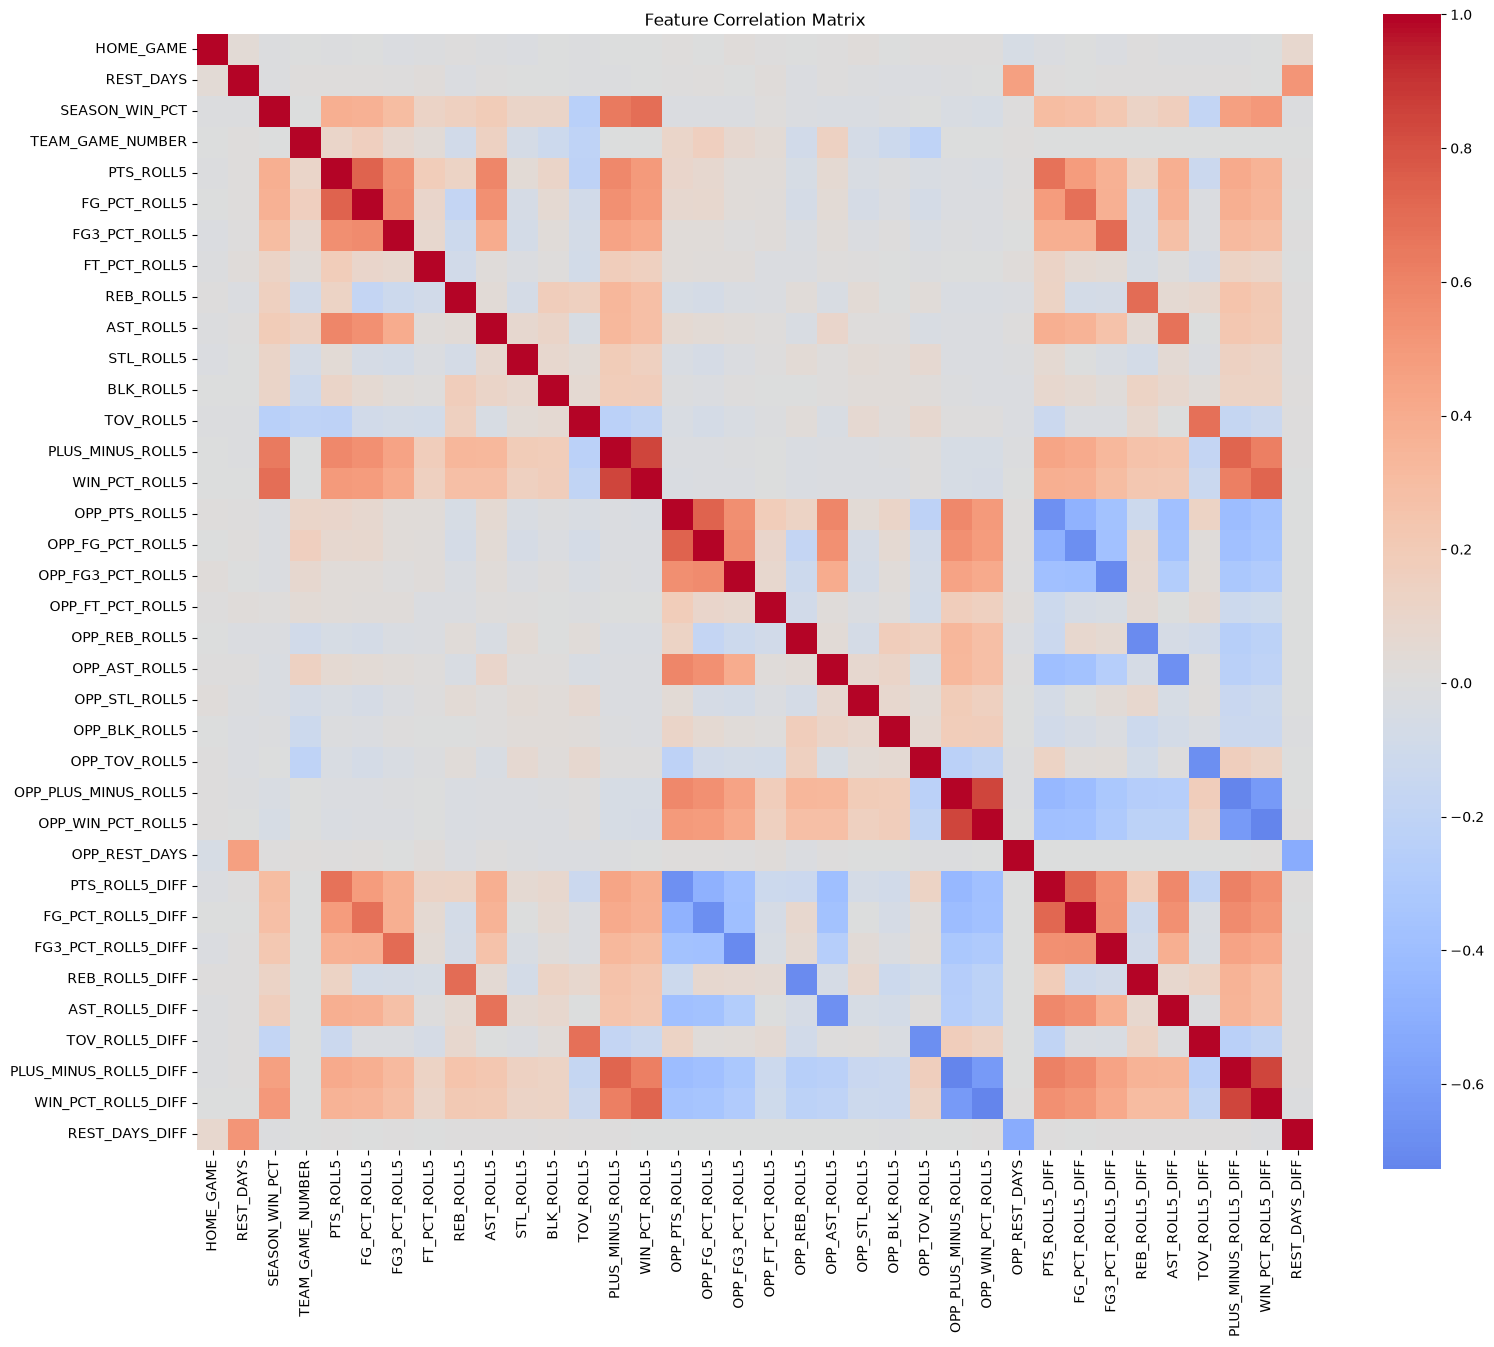

In [519]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = X_train.corr()

plt.figure(figsize=(18, 15))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Feature Correlation Matrix")
plt.show()

In [520]:
corr_matrix = X_train.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (
    upper.stack()
         .sort_values(ascending=False)
)

high_corr[high_corr > 0.75]

PLUS_MINUS_ROLL5_DIFF  WIN_PCT_ROLL5_DIFF    0.849563
PLUS_MINUS_ROLL5       WIN_PCT_ROLL5         0.846626
OPP_PLUS_MINUS_ROLL5   OPP_WIN_PCT_ROLL5     0.846626
dtype: float64

In [521]:
print(
    (
        X_train["PLUS_MINUS_ROLL5"]
        - X_train["OPP_PLUS_MINUS_ROLL5"]
        - X_train["PLUS_MINUS_ROLL5_DIFF"]
    ).abs().max()
)

0.0


### Predict

In [522]:
y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(X_test)[:, 1]

logistic_model.predict(X_test)
logistic_model.predict_proba(X_test)

array([[0.8570702 , 0.1429298 ],
       [0.58652854, 0.41347146],
       [0.72530274, 0.27469726],
       ...,
       [0.63618245, 0.36381755],
       [0.4166098 , 0.5833902 ],
       [0.68883596, 0.31116404]], shape=(2428, 2))

In [523]:
print(
    (
        X_train["PLUS_MINUS_ROLL5"]
        - X_train["OPP_PLUS_MINUS_ROLL5"]
        - X_train["PLUS_MINUS_ROLL5_DIFF"]
    ).abs().max()
)

0.0


### Evaluate

In [524]:
# Accuracy (correct predictions / total predictions)
accuracy = accuracy_score(y_test, y_pred)

# Precision (true positives / (true positives + false positives))   
precision = precision_score(y_test, y_pred)

# Recall (true positives / (true positives + false negatives))
recall = recall_score(y_test, y_pred)

# F1 Score (harmonic mean of precision and recall)
f1 = f1_score(y_test, y_pred)

# ROC AUC (area under the ROC curve)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")
print(f"ROC AUC  : {roc_auc:.3f}")

Accuracy : 0.644
Precision: 0.643
Recall   : 0.647
F1 Score : 0.645
ROC AUC  : 0.711


### Notes:
The engineered differential features introduced perfect linear relationships with the corresponding team and opponent statistics. This resulted in infinite VIF values, indicating perfect multicollinearity. Because the primary objective was predictive performance rather than statistical inference, the complete feature set was retained. Logistic Regression uses L2 regularization to mitigate this issue, while tree-based models are generally less sensitive to multicollinearity.

## Decision Tree

In [525]:
from sklearn.tree import DecisionTreeClassifier


### Build Model

In [526]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# reduced overfitting by setting max_depth

### Train

In [527]:
decision_tree.fit(X_train, y_train)

print("Training complete.")

Training complete.


### Predict

In [528]:
y_pred_tree = decision_tree.predict(X_test)

y_prob_tree = decision_tree.predict_proba(X_test)[:, 1]

### Evaluate

In [529]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)

tree_precision = precision_score(y_test, y_pred_tree)

tree_recall = recall_score(y_test, y_pred_tree)

tree_f1 = f1_score(y_test, y_pred_tree)

tree_auc = roc_auc_score(y_test, y_prob_tree)

print(f"Accuracy : {tree_accuracy:.3f}")
print(f"Precision: {tree_precision:.3f}")
print(f"Recall   : {tree_recall:.3f}")
print(f"F1 Score : {tree_f1:.3f}")
print(f"ROC AUC  : {tree_auc:.3f}")

Accuracy : 0.637
Precision: 0.647
Recall   : 0.603
F1 Score : 0.624
ROC AUC  : 0.691


#### Confusion Matrix

In [530]:
tree_cm = confusion_matrix(
    y_test,
    y_pred_tree
)

print(tree_cm)

[[815 399]
 [482 732]]


#### Classification Report

In [531]:
print(
    classification_report(
        y_test,
        y_pred_tree
    )
)

              precision    recall  f1-score   support

           0       0.63      0.67      0.65      1214
           1       0.65      0.60      0.62      1214

    accuracy                           0.64      2428
   macro avg       0.64      0.64      0.64      2428
weighted avg       0.64      0.64      0.64      2428



### Feature Importance

In [532]:
importance = (
    pd.DataFrame(
        {
            "Feature": X_train.columns,
            "Importance": decision_tree.feature_importances_,
        }
    )
    .sort_values("Importance", ascending=False)
)

importance

,Feature,Importance
33,PLUS_MINUS_ROLL5_DIFF,0.461061
2,SEASON_WIN_PCT,0.198891
0,HOME_GAME,0.101982
3,TEAM_GAME_NUMBER,0.055895
24,OPP_PLUS_MINUS_ROLL5,0.036935
35,REST_DAYS_DIFF,0.026001
16,OPP_FG_PCT_ROLL5,0.023451
32,TOV_ROLL5_DIFF,0.018150
17,OPP_FG3_PCT_ROLL5,0.012254
9,AST_ROLL5,0.009759


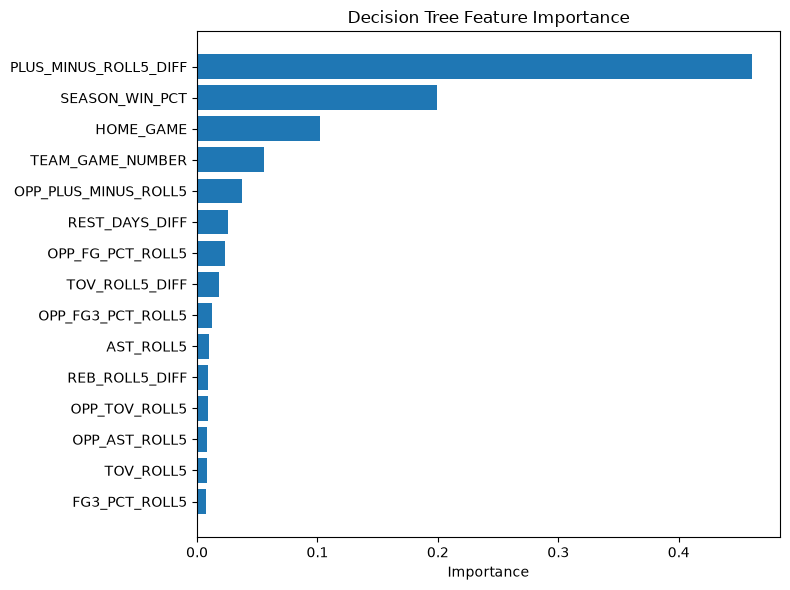

In [533]:
import matplotlib.pyplot as plt

top_features = (
    importance.head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"],
)

plt.xlabel("Importance")
plt.title("Decision Tree Feature Importance")

plt.tight_layout()
plt.show()

### Notes
The baseline Decision Tree substantially underperformed Logistic Regression, indicating that an unconstrained tree overfit the training data and failed to generalize well to the 2025–26 test season. Limiting the tree depth to five levels significantly improved performance, increasing accuracy from 55.0% to 63.7% and ROC AUC from 0.550 to 0.691. These results demonstrate the importance of controlling model complexity to reduce overfitting.

Feature importance analysis identified recent point differential (PLUS_MINUS_ROLL5_DIFF), season win percentage, and home court advantage as the most influential predictors, reinforcing conclusions drawn from the Logistic Regression model. However, despite the improvement, the tuned Decision Tree still performed slightly below Logistic Regression, suggesting that a single tree may not fully capture the complex relationships present in NBA game outcomes.

Because individual Decision Trees are prone to high variance and overfitting, the next step is to evaluate a Random Forest model, which combines predictions from many decision trees to improve generalization and predictive performance.

## Random Forest

In [534]:
from sklearn.ensemble import RandomForestClassifier

### Build Model

In [535]:
random_forest = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

### Train

In [536]:
random_forest.fit(
    X_train,
    y_train
)

print("Training complete.")

Training complete.


### Predict

In [537]:
y_pred_rf = random_forest.predict(X_test)

y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

### Evaluate

In [538]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(y_test, y_pred_rf)

rf_recall = recall_score(y_test, y_pred_rf)

rf_f1 = f1_score(y_test, y_pred_rf)

rf_auc = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy : {rf_accuracy:.3f}")
print(f"Precision: {rf_precision:.3f}")
print(f"Recall   : {rf_recall:.3f}")
print(f"F1 Score : {rf_f1:.3f}")
print(f"ROC AUC  : {rf_auc:.3f}")

Accuracy : 0.647
Precision: 0.648
Recall   : 0.643
F1 Score : 0.646
ROC AUC  : 0.710


#### Confusion Matrix

In [539]:
rf_cm = confusion_matrix(
    y_test,
    y_pred_rf
)

print(rf_cm)

[[790 424]
 [433 781]]


#### Classification Report

In [540]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.65      0.65      0.65      1214
           1       0.65      0.64      0.65      1214

    accuracy                           0.65      2428
   macro avg       0.65      0.65      0.65      2428
weighted avg       0.65      0.65      0.65      2428



#### Feature Importance

In [541]:
rf_importance = (
    pd.DataFrame(
        {
            "Feature": X_train.columns,
            "Importance": random_forest.feature_importances_,
        }
    )
    .sort_values("Importance", ascending=False)
)

rf_importance

,Feature,Importance
2,SEASON_WIN_PCT,0.092383
33,PLUS_MINUS_ROLL5_DIFF,0.077376
24,OPP_PLUS_MINUS_ROLL5,0.052564
13,PLUS_MINUS_ROLL5,0.042895
28,FG_PCT_ROLL5_DIFF,0.032970
16,OPP_FG_PCT_ROLL5,0.032268
5,FG_PCT_ROLL5,0.030152
7,FT_PCT_ROLL5,0.029583
18,OPP_FT_PCT_ROLL5,0.029317
3,TEAM_GAME_NUMBER,0.028668


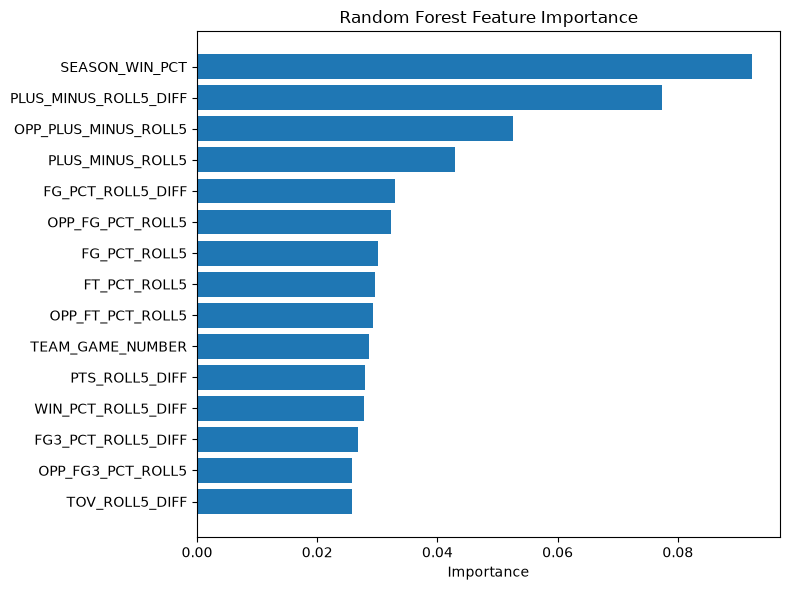

In [542]:
top_features = (
    rf_importance.head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(8,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

### Notes
The tuned Random Forest achieved the strongest overall performance among the tree-based models, improving upon both the baseline Random Forest and the tuned Decision Tree. Limiting tree depth and increasing the number of trees reduced overfitting while producing balanced feature importance estimates across the engineered statistics. Despite these improvements, the Random Forest performed similarly to Logistic Regression, suggesting that the engineered team and opponent features capture much of the predictive signal through relatively simple relationships. Nevertheless, the Random Forest demonstrates the benefits of ensemble learning and provides a robust nonlinear benchmark for comparison.

## XGBoost

In [543]:
from xgboost import XGBClassifier

### Build Model

In [544]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
)

### Train

In [545]:
xgb_model.fit(
    X_train,
    y_train
)

print("Training complete.")

Training complete.


### Predict

In [546]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

### Evaluate

In [547]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

xgb_precision = precision_score(y_test, y_pred_xgb)

xgb_recall = recall_score(y_test, y_pred_xgb)

xgb_f1 = f1_score(y_test, y_pred_xgb)

xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print(f"Accuracy : {xgb_accuracy:.3f}")
print(f"Precision: {xgb_precision:.3f}")
print(f"Recall   : {xgb_recall:.3f}")
print(f"F1 Score : {xgb_f1:.3f}")
print(f"ROC AUC  : {xgb_auc:.3f}")

Accuracy : 0.647
Precision: 0.645
Recall   : 0.656
F1 Score : 0.650
ROC AUC  : 0.699


#### Confusion Matrix

In [548]:
xgb_cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

print(xgb_cm)

[[776 438]
 [418 796]]


#### Classification Report

In [549]:
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.65      0.64      0.64      1214
           1       0.65      0.66      0.65      1214

    accuracy                           0.65      2428
   macro avg       0.65      0.65      0.65      2428
weighted avg       0.65      0.65      0.65      2428



#### Feature Importance

In [550]:
xgb_importance = (
    pd.DataFrame(
        {
            "Feature": X_train.columns,
            "Importance": xgb_model.feature_importances_,
        }
    )
    .sort_values("Importance", ascending=False)
)

xgb_importance

,Feature,Importance
33,PLUS_MINUS_ROLL5_DIFF,0.094697
2,SEASON_WIN_PCT,0.061711
0,HOME_GAME,0.059311
24,OPP_PLUS_MINUS_ROLL5,0.038592
34,WIN_PCT_ROLL5_DIFF,0.036247
35,REST_DAYS_DIFF,0.030356
1,REST_DAYS,0.029051
3,TEAM_GAME_NUMBER,0.028843
26,OPP_REST_DAYS,0.028374
25,OPP_WIN_PCT_ROLL5,0.027804


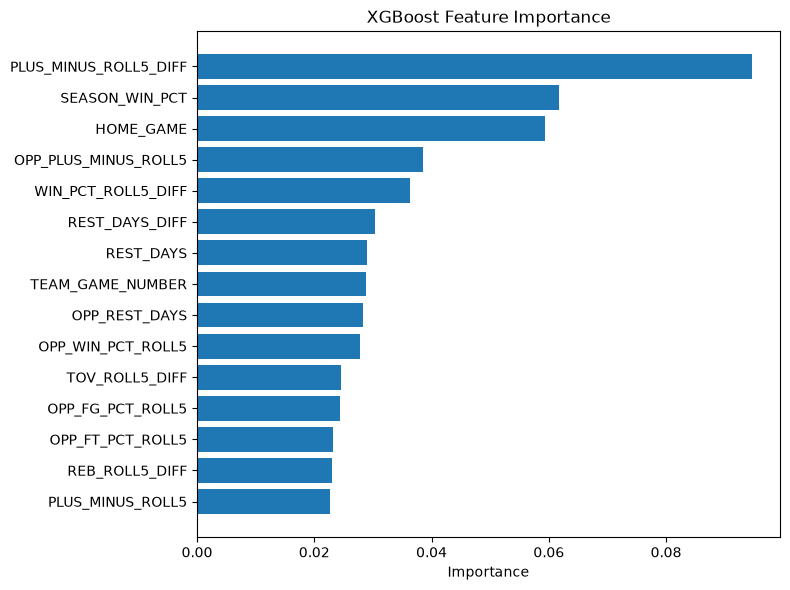

In [551]:
top_features = (
    xgb_importance.head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(8,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()

### Notes
XGBoost achieved predictive performance comparable to the tuned Random Forest and Logistic Regression models. Although gradient boosting is often one of the strongest algorithms for structured tabular data, it did not substantially outperform the simpler models in this project. This suggests that the engineered team and opponent statistics already capture much of the predictive signal through relatively simple relationships.

Feature importance analysis consistently identified recent point differential, season win percentage, and home court advantage as the strongest predictors of game outcomes. The similarity in performance across multiple algorithms indicates that future improvements are more likely to come from incorporating richer features, such as player-level statistics, injury reports, betting odds, Elo ratings, and schedule-related factors, rather than increasing model complexity alone.

## Model Comparison

The final models are compared using Accuracy, Precision, Recall, F1 Score, and ROC AUC. Because the classes are relatively balanced, Accuracy and F1 Score provide useful summaries of classification performance, while ROC AUC measures how effectively each model ranks winning teams above losing teams.

### Table

In [552]:
model_results = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Decision Tree",
            "Decision Tree (max_depth=5)",
            "Random Forest",
            "Random Forest (Tuned)",
            "XGBoost",
        ],
        "Accuracy": [
            0.644,
            0.550,
            0.637,
            0.637,
            0.647,
            0.647,
        ],
        "Precision": [
            0.643,
            0.550,
            0.647,
            0.640,
            0.648,
            0.645,
        ],
        "Recall": [
            0.647,
            0.547,
            0.603,
            0.627,
            0.643,
            0.656,
        ],
        "F1 Score": [
            0.645,
            0.549,
            0.624,
            0.633,
            0.646,
            0.650,
        ],
        "ROC AUC": [
            0.711,
            0.550,
            0.691,
            0.699,
            0.710,
            0.699,
        ],
    }
)

model_results.style.highlight_max(
    subset=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC",
    ],
    axis=0,
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.644000,0.643000,0.647000,0.645000,0.711000
1,Decision Tree,0.550000,0.550000,0.547000,0.549000,0.550000
2,Decision Tree (max_depth=5),0.637000,0.647000,0.603000,0.624000,0.691000
3,Random Forest,0.637000,0.640000,0.627000,0.633000,0.699000
4,Random Forest (Tuned),0.647000,0.648000,0.643000,0.646000,0.710000
5,XGBoost,0.647000,0.645000,0.656000,0.650000,0.699000


In [553]:
model_results.sort_values(
    "ROC AUC",
    ascending=False,
)


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.644,0.643,0.647,0.645,0.711
4,Random Forest (Tuned),0.647,0.648,0.643,0.646,0.710
3,Random Forest,0.637,0.640,0.627,0.633,0.699
5,XGBoost,0.647,0.645,0.656,0.650,0.699
2,Decision Tree (max_depth=5),0.637,0.647,0.603,0.624,0.691
1,Decision Tree,0.550,0.550,0.547,0.549,0.550


### Chart

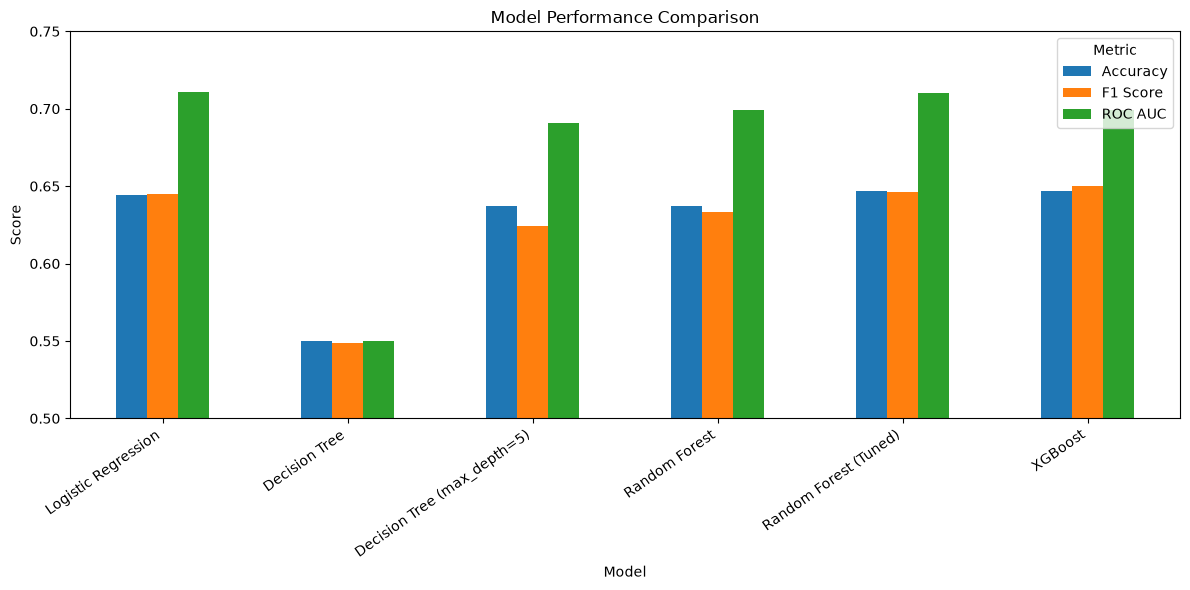

In [554]:
comparison_plot = (
    model_results.set_index("Model")[
        ["Accuracy", "F1 Score", "ROC AUC"]
    ]
)

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6),
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0.5, 0.75)
plt.xticks(rotation=35, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


### Model Selection

No single model dominated every evaluation metric.

The tuned Random Forest and XGBoost achieved the highest overall Accuracy of 64.7%. XGBoost achieved the highest Recall and F1 Score, indicating that it identified a slightly larger percentage of actual wins while maintaining balanced classification performance.

Logistic Regression achieved the highest ROC AUC of 0.711, narrowly exceeding the tuned Random Forest at 0.710. This indicates that Logistic Regression was marginally better at ranking likely winners above likely losers across different classification thresholds.

Because the performance differences between Logistic Regression, tuned Random Forest, and XGBoost were very small, the models should be considered broadly comparable. Logistic Regression provides the strongest combination of simplicity, interpretability, and ranking performance, while Random Forest and XGBoost provide nonlinear alternatives with slightly stronger Accuracy or F1 performance.

## Key Findings

### Predictive Performance

The strongest models achieved approximately 64–65% Accuracy on the held-out test season. Logistic Regression, tuned Random Forest, and XGBoost produced similar results despite having substantially different levels of complexity.

This suggests that much of the available predictive signal was captured through the engineered features rather than through increasingly complex algorithms.

### Effect of Model Complexity

The unrestricted Decision Tree performed poorly, achieving only 55.0% Accuracy and a ROC AUC of 0.550. This indicated severe overfitting.

Restricting the tree to a maximum depth of five improved Accuracy to 63.7% and ROC AUC to 0.691. This demonstrated that controlling model complexity significantly improved generalization.

The tuned Random Forest also improved upon its baseline version after maximum depth and minimum leaf-size constraints were introduced.

### Most Important Features

The most influential predictors across the models were:

- Recent point differential between the team and opponent
- Season win percentage
- Home-court advantage
- Team and opponent recent plus-minus
- Recent win-percentage differential
- Rest-day differential

The repeated appearance of these features across Logistic Regression, Decision Tree, Random Forest, and XGBoost suggests that they contain meaningful and stable predictive information.

### Multicollinearity

Several raw team statistics, opponent statistics, and differential features had exact linear relationships. For example, the point-differential feature was calculated directly from the team and opponent point statistics.

This produced infinite Variance Inflation Factor values and made individual Logistic Regression coefficients less reliable for interpretation. However, Logistic Regression's regularization allowed the model to remain stable, and the issue had less impact on the tree-based models.

### Best Overall Models

- **Highest Accuracy:** Tuned Random Forest and XGBoost — 0.647
- **Highest Precision:** Tuned Random Forest — 0.648
- **Highest Recall:** XGBoost — 0.656
- **Highest F1 Score:** XGBoost — 0.650
- **Highest ROC AUC:** Logistic Regression — 0.711

Logistic Regression is the preferred model when interpretability and probability ranking are prioritized. XGBoost is the preferred model when balanced classification performance and win detection are prioritized.

## Conclusion

This notebook developed and evaluated Logistic Regression, Decision Tree, Random Forest, and XGBoost models for predicting NBA game outcomes using historical team performance, opponent statistics, rolling averages, rest information, and home-court advantage.

The strongest models achieved approximately 64–65% Accuracy on unseen games. Logistic Regression produced the highest ROC AUC, the tuned Random Forest produced the highest Precision, and XGBoost produced the highest Recall and F1 Score.

The results demonstrate that more complex models do not automatically produce better predictions. Logistic Regression remained highly competitive with ensemble tree methods, indicating that the engineered features captured much of the available predictive signal through relatively simple relationships.

Recent point differential, season win percentage, and home-court advantage consistently emerged as the strongest predictors. These findings support the value of combining long-term team strength with short-term performance and game-context variables.

The final results provide a strong predictive baseline and establish a foundation for future model explainability, simulation, and deployment work.

### Limitations

The current model relies primarily on team-level historical statistics and does not include several factors that may materially affect NBA game outcomes:

- Player injuries and availability
- Starting lineup changes
- Individual player performance
- Trades and roster changes
- Travel distance and schedule difficulty
- Coaching changes
- Betting-market information
- Playoff-specific context

Rolling statistics also summarize recent team performance but may not fully capture sudden changes in team quality or lineup composition.

### Future Improvements

Future versions of the prediction engine could improve performance by:

1. Incorporating player-level rolling statistics and expected lineups
2. Adding injury and availability information
3. Creating Elo or power-rating features
4. Including travel distance, back-to-back games, and schedule difficulty
5. Using time-series cross-validation for more robust model selection
6. Performing systematic hyperparameter optimization
7. Calibrating predicted probabilities
8. Applying SHAP to explain global and individual predictions
9. Simulating game and playoff outcomes
10. Deploying predictions through an interactive dashboard